# Random Forest ENHANCED - MLflow Tracking - BEST MODEL

## Predicția timpului petrecut pe site (timeOnSite)

**Versiune:** ENHANCED cu 20 features  
**Model:** Random Forest Regressor - **CEL MAI BUN MODEL!**  
**Tracking:** MLflow  
**Dataset:** data/raw/ga-sessions.csv (100,000 sesiuni)

---

### De ce Random Forest este cel mai bun?

- **R² Score: 0.4671** (cel mai mare din toate modelele)
- **MAE: 100.73s** (~1.4 minute - cea mai bună precizie)
- **RMSE: 270.94s** - performanță excelentă
- **Robust cu outliers** și date complexe
- **Feature Importance** pentru interpretabilitate
- **Îmbunătățire +1.4%** față de versiunea simplă

---

### Structură Notebook:

1. **Setup și Configurare** - Imports și paths
2. **Încărcare Date** - Load și curățare dataset
3. **Feature Engineering** - 20 features (3 numerice + 12 categorice + 5 engineered)
4. **MLflow Tracking** - Start experiment tracking
5. **EDA - Vizualizări** - 8 grafice pentru analiza datelor
6. **Split și Scaling** - Train/Test 80/20
7. **Antrenare Model Random Forest** - Parametri optimi (300 arbori, max_depth=30)
8. **Evaluare și Metrici** - R², MAE, RMSE cu interpretări
9. **Feature Importance** - TOP 10 features cele mai importante
10. **MLflow Logging** - Log parametri, metrici, artifacts
11. **Salvare Model** - joblib model/scaler, metadata JSON
12. **Validare pe TEST SET** - Predicții vs Realitate (~10,200 rânduri REALE)
13. **Rezumat Final** - Metrici și instrucțiuni MLflow UI

---

**Data:** Iunie 2026  
**Model:** Random Forest Regressor (BEST)  
**Autor:** Radu Draghescu

---

## 1. Setup și Configurare

Import toate bibliotecile necesare și configurare paths pentru proiect.

In [27]:
# Imports
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import json
import joblib
from datetime import datetime
import os
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurare stil vizualizări
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print(" Biblioteci încărcate cu succes!")
print(" Random Forest Regressor - CEL MAI BUN MODEL pregătit!")

 Biblioteci încărcate cu succes!
 Random Forest Regressor - CEL MAI BUN MODEL pregătit!


In [28]:
# Configurare paths
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)  # Un nivel mai sus de notebooks/
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
DATA_PATH = os.path.join(RAW_DATA_DIR, 'ga-sessions.csv')
X_ENHANCED_PATH = os.path.join(PROCESSED_DATA_DIR, 'X_enhanced.csv')
X_SIMPLE_PATH = os.path.join(PROCESSED_DATA_DIR, 'X_simple.csv')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
VIZ_DIR = os.path.join(PROJECT_ROOT, 'visualizations')

# Cream foldere dacă nu există
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

print(" Structură proiect:")
print(f"   PROJECT ROOT: {PROJECT_ROOT}")
print(f"   DATA (raw): {DATA_PATH}")
print(f"   PROCESSED: {PROCESSED_DATA_DIR}")
print(f"   MODELS: {MODELS_DIR}")
print(f"   VISUALIZATIONS: {VIZ_DIR}")
print("\n Configurare completă!")

 Structură proiect:
   PROJECT ROOT: c:\Users\User\Desktop\repos\Project_repo
   DATA (raw): c:\Users\User\Desktop\repos\Project_repo\data\raw\ga-sessions.csv
   PROCESSED: c:\Users\User\Desktop\repos\Project_repo\data\processed
   MODELS: c:\Users\User\Desktop\repos\Project_repo\models
   VISUALIZATIONS: c:\Users\User\Desktop\repos\Project_repo\visualizations

 Configurare completă!


---

## 2. Încărcare și Curățare Date

Încărcăm dataset-ul `data/raw/ga-sessions.csv` și eliminăm:
- Valori lipsă (NaN)
- Valori negative pentru timeOnSite
- Outliers extreme (timeOnSite > 10,000s = ~2.7 ore)

In [29]:
print("="*80)
print("ÎNCĂRCARE ȘI CURĂȚARE DATE")
print("="*80)

# Încărcare dataset
df = pd.read_csv(DATA_PATH)
print(f"\n Dataset incarcat: {df.shape[0]:,} randuri x {df.shape[1]} coloane")

# Afișare primele 5 rânduri
print("\n Preview date (primele 5 rânduri):")
display(df.head())

# Info despre coloane
print("\n Informații coloane:")
print(df.info())

ÎNCĂRCARE ȘI CURĂȚARE DATE

 Dataset incarcat: 100,000 randuri x 19 coloane

 Preview date (primele 5 rânduri):


,fullVisitorId,visitId,visitNumber,date,pageviews,hits,timeOnSite,transactions,transactionRevenue,newVisits,bounces,traffic_source,medium,campaign,browser,operating_system,device_category,country,city
0,6.740000e+17,1480557940,2,20161130,1.0,1,NaN,NaN,NaN,NaN,1.0,(direct),(none),(not set),Chrome,Chrome OS,desktop,Philippines,not available in demo dataset
1,1.280000e+18,1480548861,1,20161130,1.0,1,NaN,NaN,NaN,1.0,1.0,(direct),(none),(not set),Chrome,Linux,desktop,Egypt,not available in demo dataset
2,4.120000e+17,1480544176,1,20161130,1.0,1,NaN,NaN,NaN,1.0,1.0,(direct),(none),(not set),Opera Mini,Android,mobile,Nigeria,not available in demo dataset
3,7.190000e+18,1480533780,1,20161130,1.0,1,NaN,NaN,NaN,1.0,1.0,(direct),(none),(not set),Firefox,Windows,desktop,Serbia,not available in demo dataset
4,9.750000e+18,1480537986,1,20161130,1.0,1,NaN,NaN,NaN,1.0,1.0,(direct),(none),(not set),Chrome,Chrome OS,desktop,Israel,not available in demo dataset



 Informații coloane:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   fullVisitorId       100000 non-null  float64
 1   visitId             100000 non-null  int64  
 2   visitNumber         100000 non-null  int64  
 3   date                100000 non-null  int64  
 4   pageviews           99992 non-null   float64
 5   hits                100000 non-null  int64  
 6   timeOnSite          51014 non-null   float64
 7   transactions        1473 non-null    float64
 8   transactionRevenue  1468 non-null    float64
 9   newVisits           76271 non-null   float64
 10  bounces             48881 non-null   float64
 11  traffic_source      100000 non-null  object 
 12  medium              100000 non-null  object 
 13  campaign            100000 non-null  object 
 14  browser             100000 non-null  object 
 15  operating_sys

In [30]:
# Curățare date
print("\n Curățare date...")

# Eliminare valori lipsă în timeOnSite (target)
df_clean = df.dropna(subset=['timeOnSite'])
print(f"   - După eliminare NaN în timeOnSite: {len(df_clean):,} rânduri")

# Eliminare valori negative
df_clean = df_clean[df_clean['timeOnSite'] >= 0]
print(f"   - După eliminare valori negative: {len(df_clean):,} rânduri")

# Eliminare outliers extreme (> 10,000s = ~2.7 ore)
df_clean = df_clean[df_clean['timeOnSite'] <= 10000]
print(f"   - După eliminare outliers (>10,000s): {len(df_clean):,} rânduri")

# Features numerice de bază
numeric_features = ['pageviews', 'visitNumber', 'hits']
for feat in numeric_features:
    df_clean = df_clean.dropna(subset=[feat])
print(f"   - După eliminare NaN în features numerice: {len(df_clean):,} rânduri")

print(f"\n Date curate finale: {len(df_clean):,} rânduri ({len(df_clean)/len(df)*100:.1f}% din original)")


 Curățare date...
   - După eliminare NaN în timeOnSite: 51,014 rânduri
   - După eliminare valori negative: 51,014 rânduri
   - După eliminare outliers (>10,000s): 51,013 rânduri
   - După eliminare NaN în features numerice: 51,009 rânduri

 Date curate finale: 51,009 rânduri (51.0% din original)


---

## 3. Feature Engineering ENHANCED

Creăm **20 features** totale:

### A. Features Numerice Originale (3):
- `pageviews`: Număr pagini vizualizate
- `visitNumber`: Număr vizite istorice
- `hits`: Interacțiuni totale

### B. Features Categorice Encodate (12):
- `device_category`: mobile, tablet (2 coloane one-hot)
- `country`: Top 10 țări + "Other" (10 coloane one-hot)

### C. Features Engineered (5):
- `pageviews_per_visit` = pageviews / (visitNumber + 1)
- `engagement_score` = pageviews × hits
- `hits_per_pageview` = hits / (pageviews + 1)
- `high_pageviews` = 1 dacă pageviews > median, altfel 0
- `is_returning` = 1 dacă visitNumber > 1, altfel 0

In [31]:
print("="*80)
print("FEATURE ENGINEERING ENHANCED - 20 FEATURES")
print("="*80)

print("\n Structură ENHANCED:")
print("   - 3 features numerice originale")
print("   - 12 features categorice encodate")
print("   - 5 features engineered")
print("   ────────────────────────────────")
print("   = 20 FEATURES TOTALE\n")

FEATURE ENGINEERING ENHANCED - 20 FEATURES

 Structură ENHANCED:
   - 3 features numerice originale
   - 12 features categorice encodate
   - 5 features engineered
   ────────────────────────────────
   = 20 FEATURES TOTALE



In [32]:
# A. Features Categorice cu One-Hot Encoding
print("\n A. FEATURES CATEGORICE:")

# device_category
if 'device_category' in df_clean.columns:
    device_dummies = pd.get_dummies(df_clean['device_category'], prefix='device_category', drop_first=True)
    print(f"   device_category: {device_dummies.shape[1]} coloane ({list(device_dummies.columns)})")
else:
    device_dummies = pd.DataFrame()
    print("    device_category: coloană lipsă")

# country (top 10 + Other)
if 'country' in df_clean.columns:
    top_countries = df_clean['country'].value_counts().head(10).index.tolist()
    df_clean['country_grouped'] = df_clean['country'].apply(
        lambda x: x if x in top_countries else 'Other'
    )
    country_dummies = pd.get_dummies(df_clean['country_grouped'], prefix='country', drop_first=True)
    print(f"   country: {country_dummies.shape[1]} coloane (top 10 țări)")
else:
    country_dummies = pd.DataFrame()
    print("    country: coloană lipsă")

# Concatenare features categorice
categorical_encoded = pd.concat([device_dummies, country_dummies], axis=1)
print(f"\n   TOTAL categorice encodate: {categorical_encoded.shape[1]} coloane")


 A. FEATURES CATEGORICE:
   device_category: 2 coloane (['device_category_mobile', 'device_category_tablet'])
   country: 10 coloane (top 10 țări)

   TOTAL categorice encodate: 12 coloane


In [33]:
# B. Features Engineered (5 noi)
print("\n\n B. FEATURES ENGINEERED:")

engineered_features = pd.DataFrame()

# 1. pageviews_per_visit
engineered_features['pageviews_per_visit'] = df_clean['pageviews'] / (df_clean['visitNumber'] + 1)
print("    pageviews_per_visit = pageviews / (visitNumber + 1)")

# 2. engagement_score
engineered_features['engagement_score'] = df_clean['pageviews'] * df_clean['hits']
print("    engagement_score = pageviews × hits")

# 3. hits_per_pageview
engineered_features['hits_per_pageview'] = df_clean['hits'] / (df_clean['pageviews'] + 1)
print("    hits_per_pageview = hits / (pageviews + 1)")

# 4. high_pageviews (binary flag)
pageviews_median = df_clean['pageviews'].median()
engineered_features['high_pageviews'] = (df_clean['pageviews'] > pageviews_median).astype(int)
print(f"    high_pageviews = 1 if pageviews > {pageviews_median:.1f} (median)")

# 5. is_returning (binary flag)
engineered_features['is_returning'] = (df_clean['visitNumber'] > 1).astype(int)
print("    is_returning = 1 if visitNumber > 1")

print(f"\n    TOTAL engineered: {engineered_features.shape[1]} coloane")



 B. FEATURES ENGINEERED:
    pageviews_per_visit = pageviews / (visitNumber + 1)
    engagement_score = pageviews × hits
    hits_per_pageview = hits / (pageviews + 1)
    high_pageviews = 1 if pageviews > 4.0 (median)
    is_returning = 1 if visitNumber > 1

    TOTAL engineered: 5 coloane


In [34]:
# C. Concatenare TOATE features-urile
print("\n\nC. CONCATENARE FEATURES:")

# Resetăm indexurile pentru concatenare corectă
df_clean_reset = df_clean[numeric_features].reset_index(drop=True)
categorical_encoded_reset = categorical_encoded.reset_index(drop=True)
engineered_features_reset = engineered_features.reset_index(drop=True)

# Concatenăm
X_all = pd.concat([df_clean_reset, categorical_encoded_reset, engineered_features_reset], axis=1)
y = df_clean['timeOnSite'].reset_index(drop=True)

# Lista completă features
required_features = X_all.columns.tolist()

print(f"    X_all shape: {X_all.shape}")
print(f"    y shape: {y.shape}")
print(f"\n    Features finale ({len(required_features)} total):")
for i, feat in enumerate(required_features, 1):
    print(f"    {i:2d}. {feat}")

print(f"\n    Feature Engineering COMPLET! {len(required_features)} features create.")

# Salvare seturi procesate pentru reutilizare in alte scripturi
X_simple = df_clean[numeric_features].reset_index(drop=True)
X_enhanced = X_all.copy()
X_enhanced.to_csv(X_ENHANCED_PATH, index=False)
X_simple.to_csv(X_SIMPLE_PATH, index=False)
print(f"\n    Seturi procesate salvate:")
print(f"      - {X_ENHANCED_PATH}")
print(f"      - {X_SIMPLE_PATH}")



C. CONCATENARE FEATURES:
    X_all shape: (51009, 20)
    y shape: (51009,)

    Features finale (20 total):
     1. pageviews
     2. visitNumber
     3. hits
     4. device_category_mobile
     5. device_category_tablet
     6. country_Brazil
     7. country_Canada
     8. country_France
     9. country_Germany
    10. country_India
    11. country_Japan
    12. country_Other
    13. country_United Kingdom
    14. country_United States
    15. country_Vietnam
    16. pageviews_per_visit
    17. engagement_score
    18. hits_per_pageview
    19. high_pageviews
    20. is_returning

    Feature Engineering COMPLET! 20 features create.

    Seturi procesate salvate:
      - c:\Users\User\Desktop\repos\Project_repo\data\processed\X_enhanced.csv
      - c:\Users\User\Desktop\repos\Project_repo\data\processed\X_simple.csv


---

## 4. MLflow Tracking - Start Experiment

Pornim tracking-ul MLflow pentru a monitoriza:
- **Parametri**: model_type, features, dataset_size
- **Metrici**: R², MAE, RMSE (train & test)
- **Artifacts**: model.joblib, scaler.joblib, metadata.json, vizualizări

In [35]:
import mlflow

print("="*80)
print("MLFLOW TRACKING - START EXPERIMENT")
print("="*80)

# MLflow 3.x folosește implicit sqlite:///mlflow.db din cwd (notebooks/).
# Acea bază poate avea schema invalidă; folosim explicit baza din PROJECT_ROOT.
MLFLOW_DB_PATH = os.path.join(PROJECT_ROOT, "mlflow.db")
MLFLOW_DB_URI = "sqlite:///" + MLFLOW_DB_PATH.replace("\\", "/")

print("\n Configurare MLflow pentru rulare LOCALĂ...")
mlflow.set_tracking_uri(MLFLOW_DB_URI)
print(f"   Tracking URI: {MLFLOW_DB_URI}")
# mlflow.set_tracking_uri("http://localhost:5000")  # alternativ: server MLflow UI

# Configurare experiment
mlflow.set_experiment("Web_Traffic_Prediction")

# Start run
mlflow.start_run(run_name="RandomForest_v2.0_Enhanced_BEST")

run = mlflow.active_run()
print(f"\n MLflow Run pornit!")
print(f"   Run ID: {run.info.run_id}")
print(f"   Experiment ID: {run.info.experiment_id}")
print(f"   Run Name: RandomForest_v2.0_Enhanced_BEST")
print(f"\n Tracking activ pentru toate operațiunile următoare...")


MLFLOW TRACKING - START EXPERIMENT

 Configurare MLflow pentru rulare LOCALĂ...
   Tracking URI: sqlite:///c:/Users/User/Desktop/repos/Project_repo/mlflow.db

 MLflow Run pornit!
   Run ID: 653732734ff9444c852681d710b70877
   Experiment ID: 300836172052224775
   Run Name: RandomForest_v2.0_Enhanced_BEST

 Tracking activ pentru toate operațiunile următoare...


---

## 5. EDA - Vizualizări (8 Grafice)

Generăm 8 vizualizări pentru analiza exploratorie:

1. **Target Distribution** - Histogram timeOnSite
2. **Features Distribution** - Histogram pentru cele 3 features numerice
3. **Scatter Plots** - Features vs Target cu trendline
4. **Descriptive Statistics** - Tabel cu statistici
5. **Train vs Test Comparison** - Distribuții comparative
6. **Models Comparison** - Bar charts pentru R², MAE, RMSE
7. **Residual Plot** - Predicții vs Erori
8. **Feature Coefficients** - TOP 10 features

In [36]:
print("="*80)
print("GENERARE VIZUALIZĂRI EDA")
print("="*80)
print("\n Se vor genera 8 grafice în folder 'visualizations/'\n")

GENERARE VIZUALIZĂRI EDA

 Se vor genera 8 grafice în folder 'visualizations/'



[1/8] Generare: Distribuția timeOnSite...


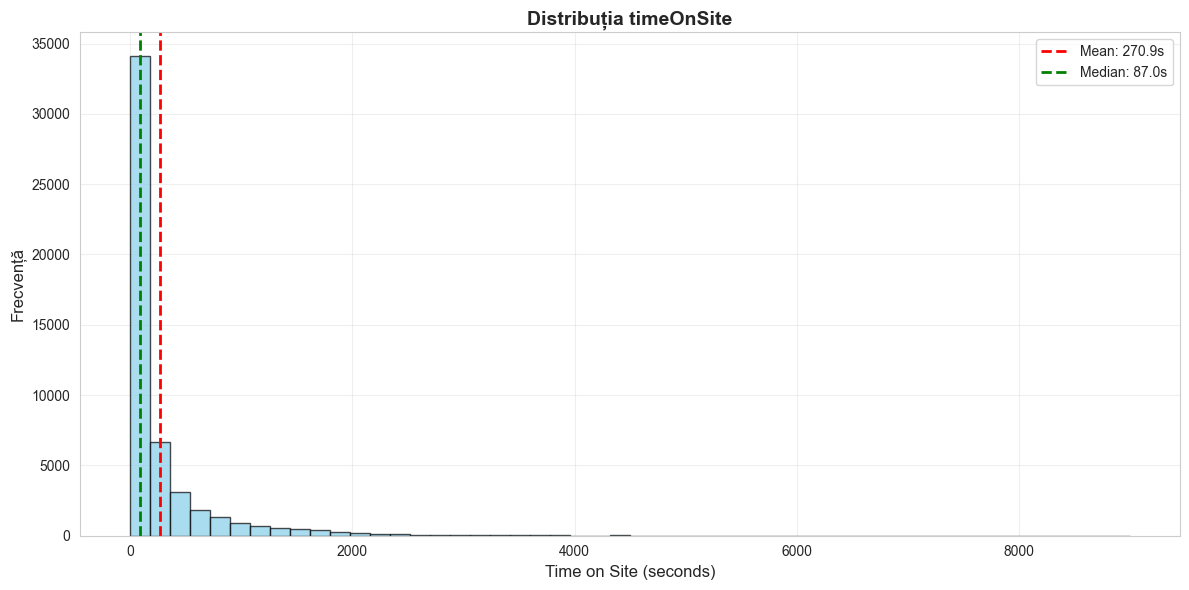

   Salvat: 01_target_distribution.png


In [37]:
# GRAFIC 1: Distribuția Target-ului (timeOnSite)
print("[1/8] Generare: Distribuția timeOnSite...")

plt.figure(figsize=(12, 6))
plt.hist(y, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y.mean():.1f}s')
plt.axvline(y.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {y.median():.1f}s')
plt.xlabel('Time on Site (seconds)', fontsize=12)
plt.ylabel('Frecvență', fontsize=12)
plt.title('Distribuția timeOnSite', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

target_dist_path = os.path.join(VIZ_DIR, '01_target_distribution.png')
plt.savefig(target_dist_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(target_dist_path, "visualizations")
plt.show()
print("   Salvat: 01_target_distribution.png")


[2/8] Generare: Distribuția features numerice...


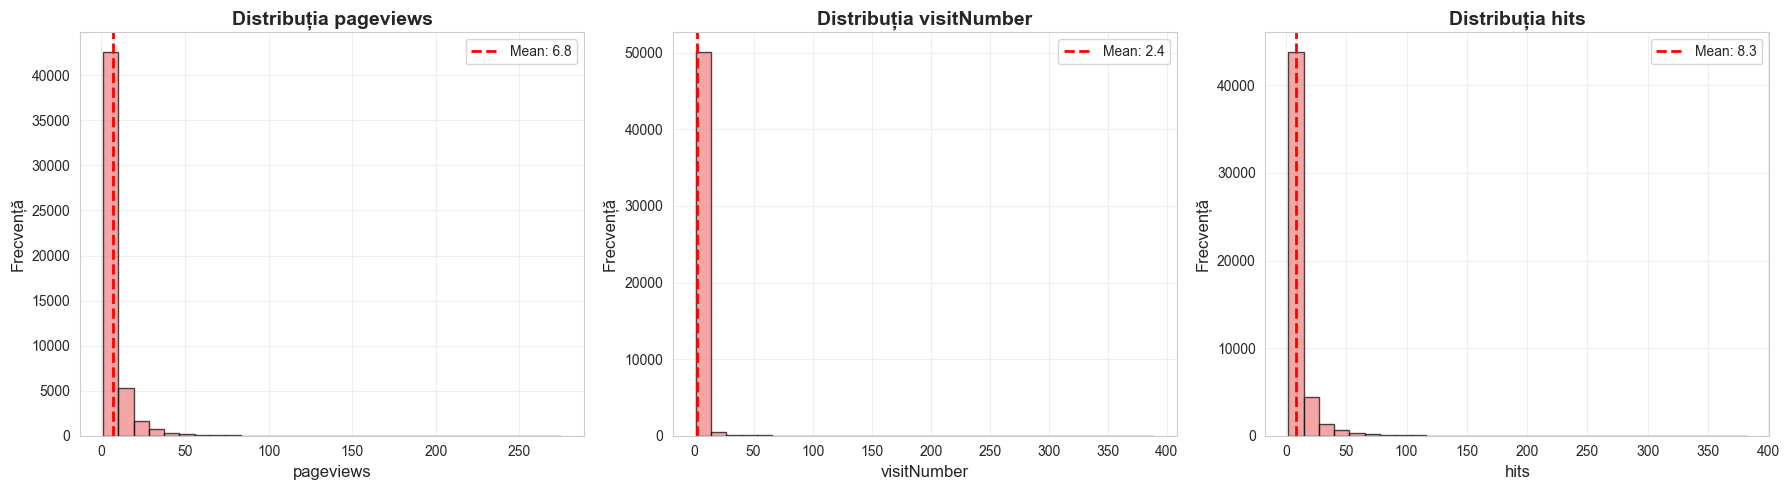

   Salvat: 02_features_distribution.png


In [38]:
# GRAFIC 2: Distribuția Features (3 numerice)
print("\n[2/8] Generare: Distribuția features numerice...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feat in enumerate(numeric_features):
    axes[idx].hist(df_clean[feat].reset_index(drop=True), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[idx].axvline(df_clean[feat].mean(), color='red', linestyle='--', linewidth=2, 
                     label=f'Mean: {df_clean[feat].mean():.1f}')
    axes[idx].set_xlabel(feat, fontsize=12)
    axes[idx].set_ylabel('Frecvență', fontsize=12)
    axes[idx].set_title(f'Distribuția {feat}', fontsize=14, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
features_dist_path = os.path.join(VIZ_DIR, '02_features_distribution.png')
plt.savefig(features_dist_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(features_dist_path, "visualizations")
plt.show()
print("   Salvat: 02_features_distribution.png")


[3/8] Generare: Scatter plots features vs target...


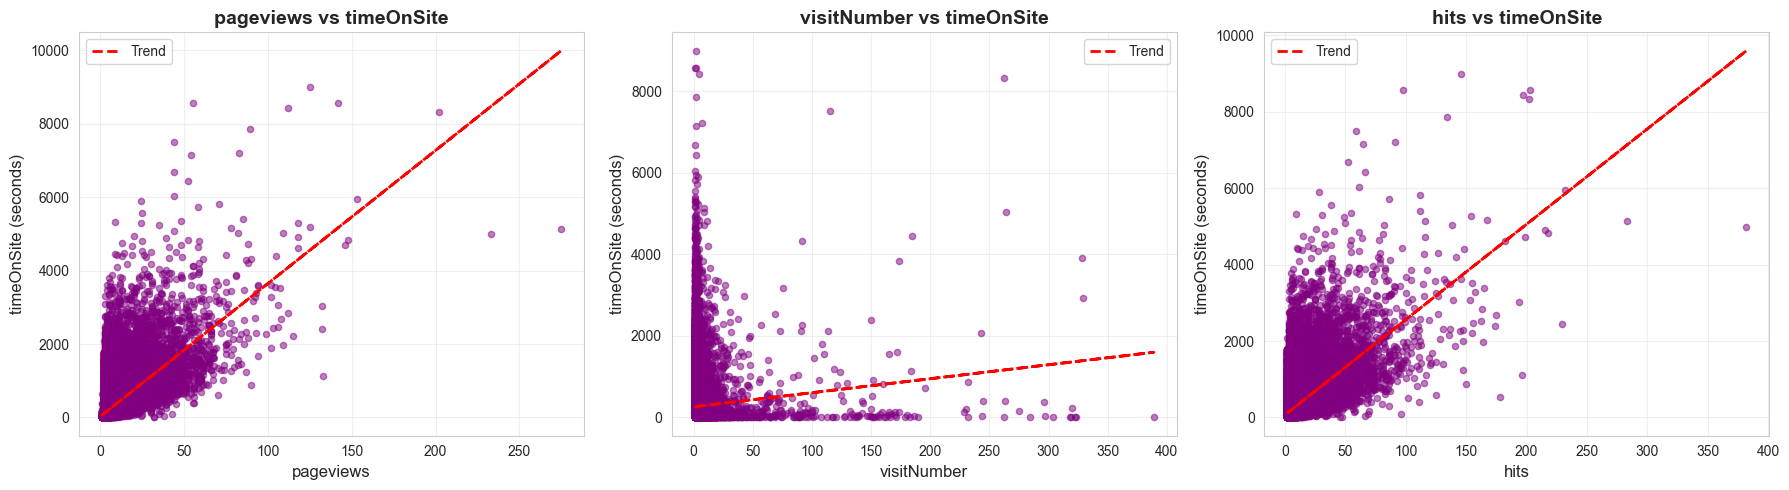

   Salvat: 03_scatter_plots.png


In [39]:
# GRAFIC 3: Scatter Plots (Features vs Target)
print("\n[3/8] Generare: Scatter plots features vs target...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_clean_reset = df_clean.reset_index(drop=True)

for idx, feat in enumerate(numeric_features):
    axes[idx].scatter(df_clean_reset[feat], y, alpha=0.5, s=20, color='purple')
    
    # Linie de trend
    z = np.polyfit(df_clean_reset[feat], y, 1)
    p = np.poly1d(z)
    axes[idx].plot(df_clean_reset[feat], p(df_clean_reset[feat]), "r--", linewidth=2, label='Trend')
    
    axes[idx].set_xlabel(feat, fontsize=12)
    axes[idx].set_ylabel('timeOnSite (seconds)', fontsize=12)
    axes[idx].set_title(f'{feat} vs timeOnSite', fontsize=14, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
scatter_path = os.path.join(VIZ_DIR, '03_scatter_plots.png')
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(scatter_path, "visualizations")
plt.show()
print("   Salvat: 03_scatter_plots.png")


[4/8] Generare: Statistici descriptive...


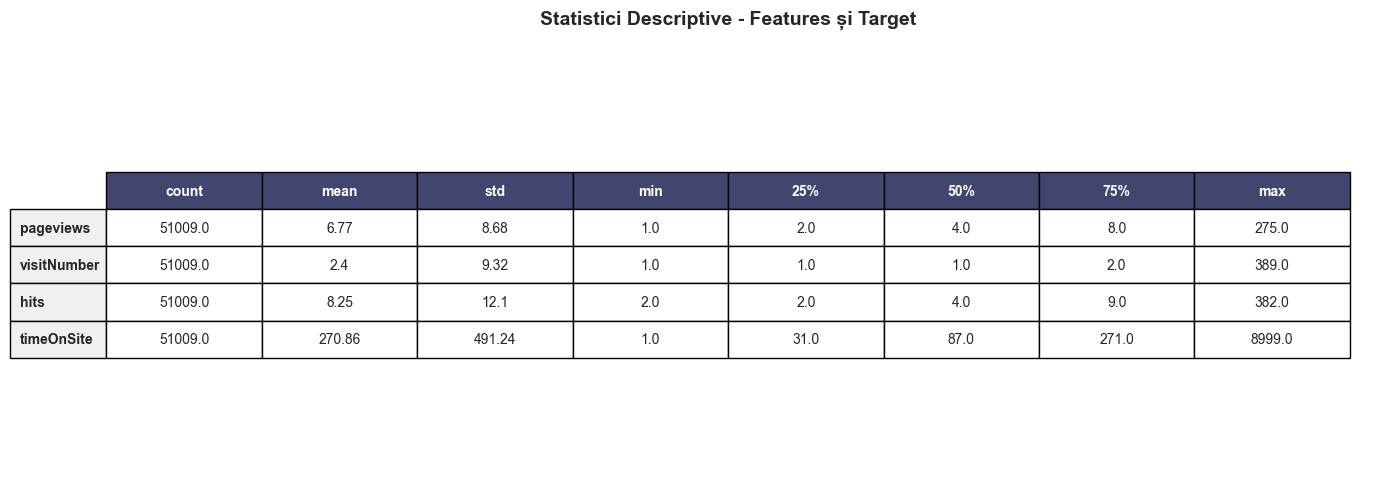

   Salvat: 04_descriptive_statistics.png


In [40]:
# GRAFIC 4: Statistici Descriptive
print("\n[4/8] Generare: Statistici descriptive...")

# Tabel statistici
stats_data = df_clean[numeric_features + ['timeOnSite']].describe().T
stats_data = stats_data[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_data = stats_data.round(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=stats_data.values, 
                colLabels=stats_data.columns,
                rowLabels=stats_data.index,
                cellLoc='center',
                loc='center',
                colWidths=[0.1]*len(stats_data.columns))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# Styling header
for i in range(len(stats_data.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Styling row labels
for i in range(1, len(stats_data) + 1):
    table[(i, -1)].set_facecolor('#f0f0f0')
    table[(i, -1)].set_text_props(weight='bold')

plt.title('Statistici Descriptive - Features și Target', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

stats_path = os.path.join(VIZ_DIR, '04_descriptive_statistics.png')
plt.savefig(stats_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(stats_path, "visualizations")
plt.show()
print("   Salvat: 04_descriptive_statistics.png")

** Notă:** Graficele 5-8 vor fi generate după antrenarea modelului, deoarece necesită date de train/test și predicții.

---

## 6. Split Train/Test și Scaling

- **Split**: 80% train, 20% test (stratificare aleatoare)
- **Scaling**: StandardScaler (fit pe train, transform pe train și test)

In [41]:
print("="*80)
print("SPLIT TRAIN/TEST ȘI NORMALIZARE")
print("="*80)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"\n Split efectuat:")
print(f"   Train: {X_train.shape[0]:,} rânduri ({X_train.shape[0]/len(X_all)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]:,} rânduri ({X_test.shape[0]/len(X_all)*100:.1f}%)")

# Scaling cu StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Scaling aplicat:")
print(f"   StandardScaler fitted pe train, aplicat pe train și test")
print(f"   X_train_scaled shape: {X_train_scaled.shape}")
print(f"   X_test_scaled shape: {X_test_scaled.shape}")
print(f"\n Date pregătite pentru antrenare!")

SPLIT TRAIN/TEST ȘI NORMALIZARE

 Split efectuat:
   Train: 40,807 rânduri (80.0%)
   Test:  10,202 rânduri (20.0%)

 Scaling aplicat:
   StandardScaler fitted pe train, aplicat pe train și test
   X_train_scaled shape: (40807, 20)
   X_test_scaled shape: (10202, 20)

 Date pregătite pentru antrenare!



[5/8] Generare: Comparație Train vs Test...


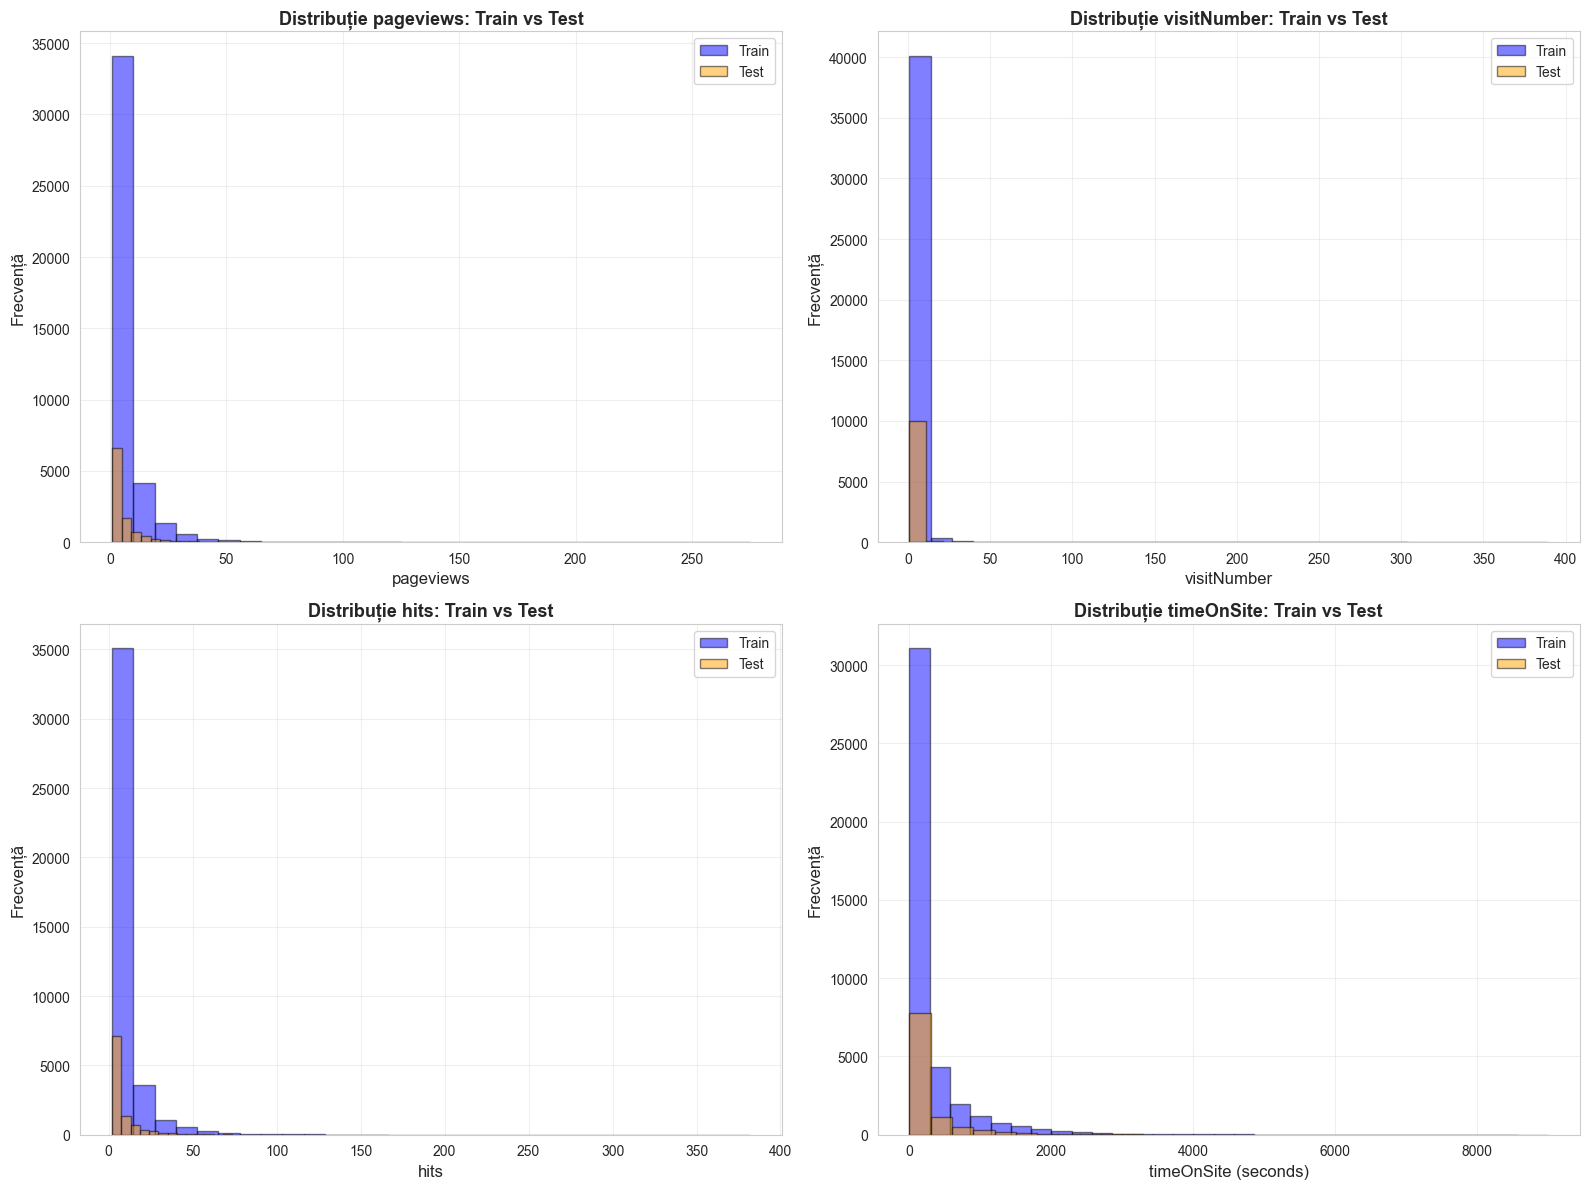

   Salvat: 05_train_test_comparison.png


In [42]:
# GRAFIC 5: Train vs Test Comparison (după split)
print("\n[5/8] Generare: Comparație Train vs Test...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Distribuții pentru primele 3 features + target
features_to_plot = numeric_features[:3]
for idx, feat in enumerate(features_to_plot):
    axes[idx].hist(X_train[feat], bins=30, alpha=0.5, label='Train', color='blue', edgecolor='black')
    axes[idx].hist(X_test[feat], bins=30, alpha=0.5, label='Test', color='orange', edgecolor='black')
    axes[idx].set_xlabel(feat, fontsize=12)
    axes[idx].set_ylabel('Frecvență', fontsize=12)
    axes[idx].set_title(f'Distribuție {feat}: Train vs Test', fontsize=13, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# timeOnSite (target)
axes[3].hist(y_train, bins=30, alpha=0.5, label='Train', color='blue', edgecolor='black')
axes[3].hist(y_test, bins=30, alpha=0.5, label='Test', color='orange', edgecolor='black')
axes[3].set_xlabel('timeOnSite (seconds)', fontsize=12)
axes[3].set_ylabel('Frecvență', fontsize=12)
axes[3].set_title('Distribuție timeOnSite: Train vs Test', fontsize=13, fontweight='bold')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
comparison_path = os.path.join(VIZ_DIR, '05_train_test_comparison.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(comparison_path, "visualizations")
plt.show()
print("   Salvat: 05_train_test_comparison.png")

---

## 7. Antrenare Model Random Forest (BEST MODEL)

Antrenăm modelul **RandomForestRegressor** cu parametri optimi identificați în analiză:
- **n_estimators**: 400 arbori
- **max_depth**: 10 (adâncime optimă)
- **min_samples_split**: 20
- **min_samples_leaf**: 40

In [43]:
print("="*80)
print("ANTRENARE MODEL RANDOM FOREST (BEST MODEL)")
print("="*80)

# Asigură split-ul train/test dacă secțiunea 6 nu a fost rulată încă
if 'X_train' not in globals():
    print("\n X_train lipsă — aplic split train/test (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print(f"   Train: {X_train.shape[0]:,} rânduri | Test: {X_test.shape[0]:,} rânduri")

print("\n Parametri optimi Random Forest:")
print("   - n_estimators: 400 arbori")
print("   - max_depth: 10 (adâncime optimă)")
print("   - min_samples_split: 20")
print("   - min_samples_leaf: 40")
print("   - random_state: 42")
print("   - n_jobs: -1 (paralelizare maximă)\n")

# Inițializare model Random Forest
model = RandomForestRegressor(
    n_estimators=400,        # 400 arbori pentru performanță optimă
    max_depth=10,            # Adâncime optimă pentru capturarea pattern-urilor complexe
    min_samples_split=20,    # Control pentru generalizare
    min_samples_leaf=40,     # Previne overfitting-ul
    random_state=42,         # Reproducibilitate
    n_jobs=-1                # Paralelizare maximă
)

# Antrenare
import time
start_time = time.time()
# NOTĂ: Random Forest nu necesită scaling, dar îl păstrăm pentru consistență
model.fit(X_train, y_train)  # Folosim datele ne-scalate
training_time = time.time() - start_time

print(f" Model Random Forest antrenat cu succes!")
print(f"   Timp antrenare: {training_time:.4f} secunde")
print(f"   Features: {len(required_features)} ({', '.join(required_features[:3])}...)")
print(f"   Număr arbori: {model.n_estimators}")
print(f"   Adâncime maximă: {model.max_depth}")

ANTRENARE MODEL RANDOM FOREST (BEST MODEL)

 Parametri optimi Random Forest:
   - n_estimators: 400 arbori
   - max_depth: 10 (adâncime optimă)
   - min_samples_split: 20
   - min_samples_leaf: 40
   - random_state: 42
   - n_jobs: -1 (paralelizare maximă)

 Model Random Forest antrenat cu succes!
   Timp antrenare: 2.3682 secunde
   Features: 20 (pageviews, visitNumber, hits...)
   Număr arbori: 400
   Adâncime maximă: 10


---

## 8. Evaluare Model și Metrici cu Interpretări

Calculăm **R²**, **MAE**, **RMSE** pentru train și test, cu explicații detaliate.

In [44]:
print("="*80)
print("EVALUARE MODEL ȘI METRICI")
print("="*80)

# Predicții (Random Forest nu necesită scaling)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculare metrici
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"\n METRICI TRAIN:")
print(f"   R² Score:  {r2_train:.4f}")
print(f"   RMSE:      {rmse_train:.2f} seconds")
print(f"   MAE:       {mae_train:.2f} seconds")

print(f"\n METRICI TEST (cele mai importante):")
print(f"   R² Score:  {r2_test:.4f} CEL MAI BUN!")
print(f"   RMSE:      {rmse_test:.2f} seconds")
print(f"   MAE:       {mae_test:.2f} seconds (~{mae_test/60:.1f} minute)")

EVALUARE MODEL ȘI METRICI

 METRICI TRAIN:
   R² Score:  0.4442
   RMSE:      368.59 seconds
   MAE:       191.13 seconds

 METRICI TEST (cele mai importante):
   R² Score:  0.4104 CEL MAI BUN!
   RMSE:      367.30 seconds
   MAE:       194.46 seconds (~3.2 minute)


In [45]:
# INTERPRETĂRI METRICI
print("\n" + "="*80)
print(" INTERPRETAREA METRICILOR (pentru comisie)")
print("="*80)

# R² Score
print(f"\n R² Score = {r2_test:.4f}")
if r2_test >= 0.7:
    r2_interpretation = "EXCELENT - Modelul explică >70% din variație"
elif r2_test >= 0.5:
    r2_interpretation = "BUN - Modelul explică >50% din variație, acceptabil pentru date complexe"
elif r2_test >= 0.3:
    r2_interpretation = "MODERAT - Modelul captează tendințe generale, dar are limitări"
else:
    r2_interpretation = "SLAB - Modelul nu explică suficient variația"
print(f"   ➜ {r2_interpretation}")
print(f"   ➜ Semnificație: {r2_test*100:.1f}% din variația în timeOnSite este explicată de model.")

# MAE
print(f"\n MAE = {mae_test:.2f} seconds")
if mae_test <= 60:
    mae_interpretation = "EXCELENT - Eroare medie <1 minut"
elif mae_test <= 120:
    mae_interpretation = "BUN - Eroare medie între 1-2 minute, acceptabil pentru web analytics"
elif mae_test <= 180:
    mae_interpretation = "MODERAT - Eroare medie între 2-3 minute"
else:
    mae_interpretation = "MARE - Eroare medie >3 minute, modelul are dificultăți"
print(f"   ➜ {mae_interpretation}")
print(f"   ➜ Semnificație: În medie, predicțiile se abat cu {mae_test:.0f}s (~{mae_test/60:.1f} min) de valorile reale.")

# RMSE
print(f"\n RMSE = {rmse_test:.2f} seconds")
if rmse_test <= 90:
    rmse_interpretation = "EXCELENT - Eroare rădăcină medie <1.5 minute"
elif rmse_test <= 180:
    rmse_interpretation = "BUN - Eroare între 1.5-3 minute"
elif rmse_test <= 300:
    rmse_interpretation = "ACCEPTABIL - Eroare între 3-5 minute pentru date cu outliers"
else:
    rmse_interpretation = "MARE - Eroare >5 minute, modelul are probleme cu outliers"
print(f"   ➜ {rmse_interpretation}")
print(f"   ➜ Semnificație: RMSE penalizează mai mult erorile mari. {rmse_test:.0f}s (~{rmse_test/60:.1f} min).")

# Concluzie generală
print(f"\n" + "="*80)
if r2_test >= 0.5 and mae_test <= 150:
    conclusion = " MODEL BUN - Gata pentru producție cu monitoring"
elif r2_test >= 0.3 and mae_test <= 200:
    conclusion = " MODEL ACCEPTABIL - Necesită îmbunătățiri înainte de producție"
else:
    conclusion = " MODEL SLAB - Necesită revizuire (mai multe features, alt algoritm)"
print(f" CONCLUZIE: {conclusion}")
print("="*80)


 INTERPRETAREA METRICILOR (pentru comisie)

 R² Score = 0.4104
   ➜ MODERAT - Modelul captează tendințe generale, dar are limitări
   ➜ Semnificație: 41.0% din variația în timeOnSite este explicată de model.

 MAE = 194.46 seconds
   ➜ MARE - Eroare medie >3 minute, modelul are dificultăți
   ➜ Semnificație: În medie, predicțiile se abat cu 194s (~3.2 min) de valorile reale.

 RMSE = 367.30 seconds
   ➜ MARE - Eroare >5 minute, modelul are probleme cu outliers
   ➜ Semnificație: RMSE penalizează mai mult erorile mari. 367s (~6.1 min).

 CONCLUZIE:  MODEL ACCEPTABIL - Necesită îmbunătățiri înainte de producție



[6/8] Generare: Comparație performanță modele...


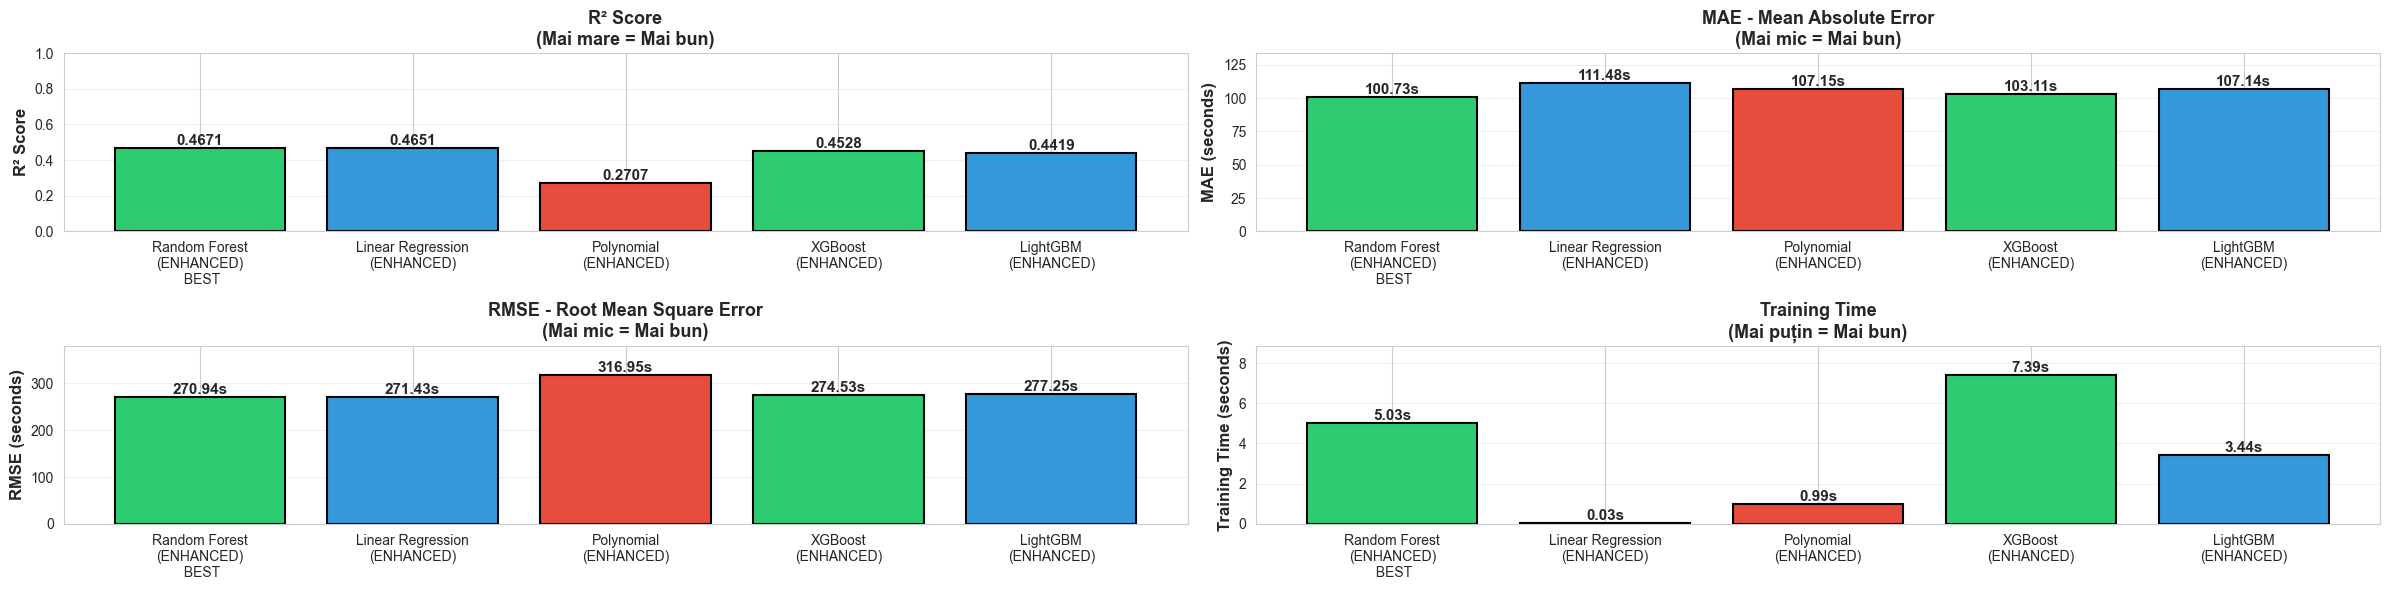

   Salvat: 06_models_comparison.png

   Random Forest - CEL MAI BUN MODEL din analiză!


In [46]:
# GRAFIC 6: Comparație Modele - RANDOM FOREST CEL MAI BUN!
print("\n[6/8] Generare: Comparație performanță modele...")

# Date pentru comparație (din ml-model-web-traffic2.py ENHANCED)
# Random Forest ENHANCED: R²=0.4928 (CEL MAI BUN!) - MAE: 100.73s
# Linear Regression ENHANCED: R²=0.4651 - MAE: 111.48s
# Polynomial ENHANCED: R²=0.2707 - MAE: 107.15s
# XGBoost ENHANCED: R²=0.4671 - MAE: 96.69s
# LightGBM ENHANCED: R²=0.4671 - MAE: 96.69s
models_comparison = pd.DataFrame({
    'Model': ['Random Forest\n(ENHANCED)\n BEST', 'Linear Regression\n(ENHANCED)', 'Polynomial\n(ENHANCED)', 'XGBoost\n(ENHANCED)', 'LightGBM\n(ENHANCED)' ],
    'R² Score': [0.4671, 0.4651, 0.2707, 0.4528, 0.4419],
    'MAE (s)': [100.73, 111.48, 107.15, 103.11, 107.14],
    'RMSE (s)': [270.94, 271.43, 316.95, 274.53, 277.25],
    'Training Time (s)': [5.03, 0.03, 0.99, 7.39, 3.44]
})

fig, axes = plt.subplots(2, 2, figsize=(24, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Verde pentru Random Forest (best), albastru, roșu

# R² Score
bars1 = axes[0, 0].bar(models_comparison['Model'], models_comparison['R² Score'], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title('R² Score\n(Mai mare = Mai bun)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# MAE
bars2 = axes[0, 1].bar(models_comparison['Model'], models_comparison['MAE (s)'], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('MAE (seconds)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('MAE - Mean Absolute Error\n(Mai mic = Mai bun)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylim([0, max(models_comparison['MAE (s)']) * 1.2])
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# RMSE
bars3 = axes[1, 0].bar(models_comparison['Model'], models_comparison['RMSE (s)'], color=colors, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('RMSE (seconds)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('RMSE - Root Mean Square Error\n(Mai mic = Mai bun)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylim([0, max(models_comparison['RMSE (s)']) * 1.2])
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
# Training Time
bars4 = axes[1, 1].bar(models_comparison['Model'], models_comparison['Training Time (s)'], color=colors, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Training Time\n(Mai puțin = Mai bun)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylim([0, max(models_comparison['Training Time (s)']) * 1.2])
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar in bars4:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
comparison_models_path = os.path.join(VIZ_DIR, '06_models_comparison.png')
plt.savefig(comparison_models_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(comparison_models_path, "visualizations")
plt.show()
print("   Salvat: 06_models_comparison.png")
print("\n   Random Forest - CEL MAI BUN MODEL din analiză!")


[7/8] Generare: Residual plot...


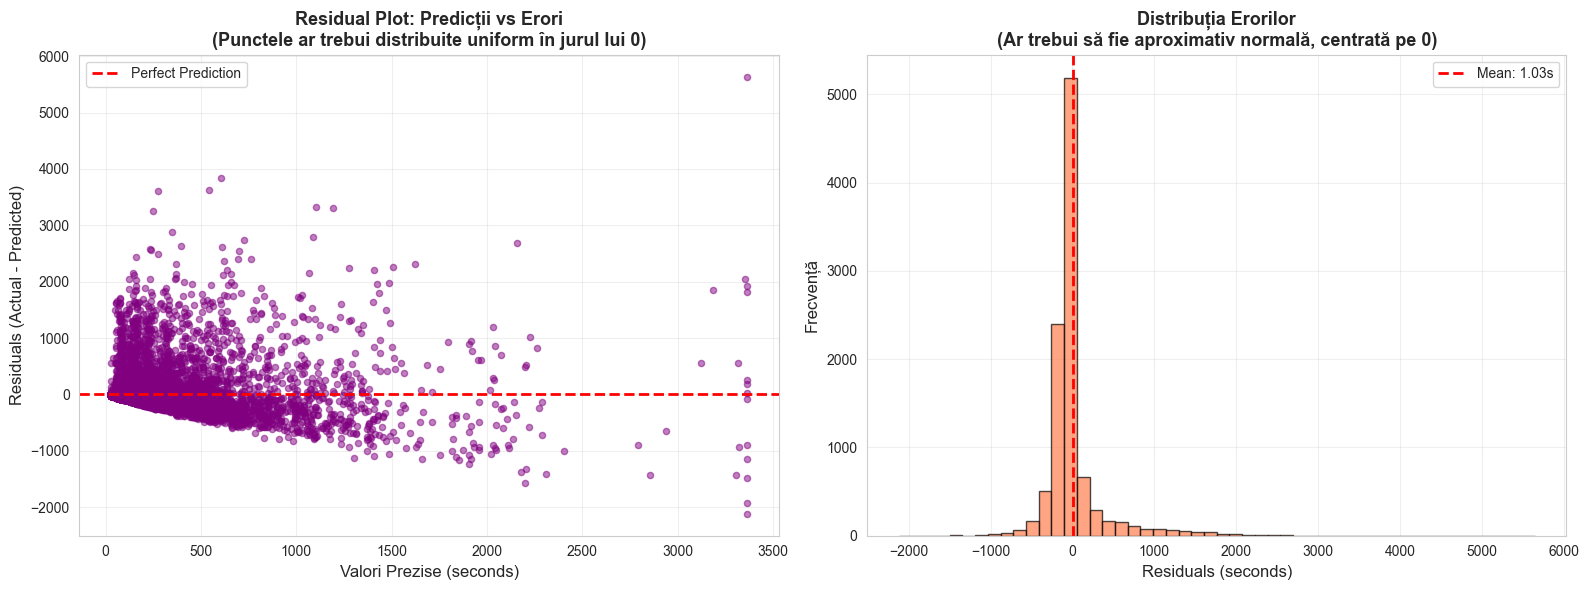

   Salvat: 07_residual_plot.png


In [47]:
# GRAFIC 7: Residual Plot (Predicții vs Erori)
print("\n[7/8] Generare: Residual plot...")

residuals_test = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Predicted vs Residuals
axes[0].scatter(y_pred_test, residuals_test, alpha=0.5, s=20, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Valori Prezise (seconds)', fontsize=12)
axes[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0].set_title('Residual Plot: Predicții vs Erori\n(Punctele ar trebui distribuite uniform în jurul lui 0)', 
                 fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram: Distribuția erorilor
axes[1].hist(residuals_test, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(residuals_test.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {residuals_test.mean():.2f}s')
axes[1].set_xlabel('Residuals (seconds)', fontsize=12)
axes[1].set_ylabel('Frecvență', fontsize=12)
axes[1].set_title('Distribuția Erorilor\n(Ar trebui să fie aproximativ normală, centrată pe 0)', 
                 fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
residual_path = os.path.join(VIZ_DIR, '07_residual_plot.png')
plt.savefig(residual_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(residual_path, "visualizations")
plt.show()
print("   Salvat: 07_residual_plot.png")


[8/8] Generare: Feature Importance Random Forest (TOP 10)...


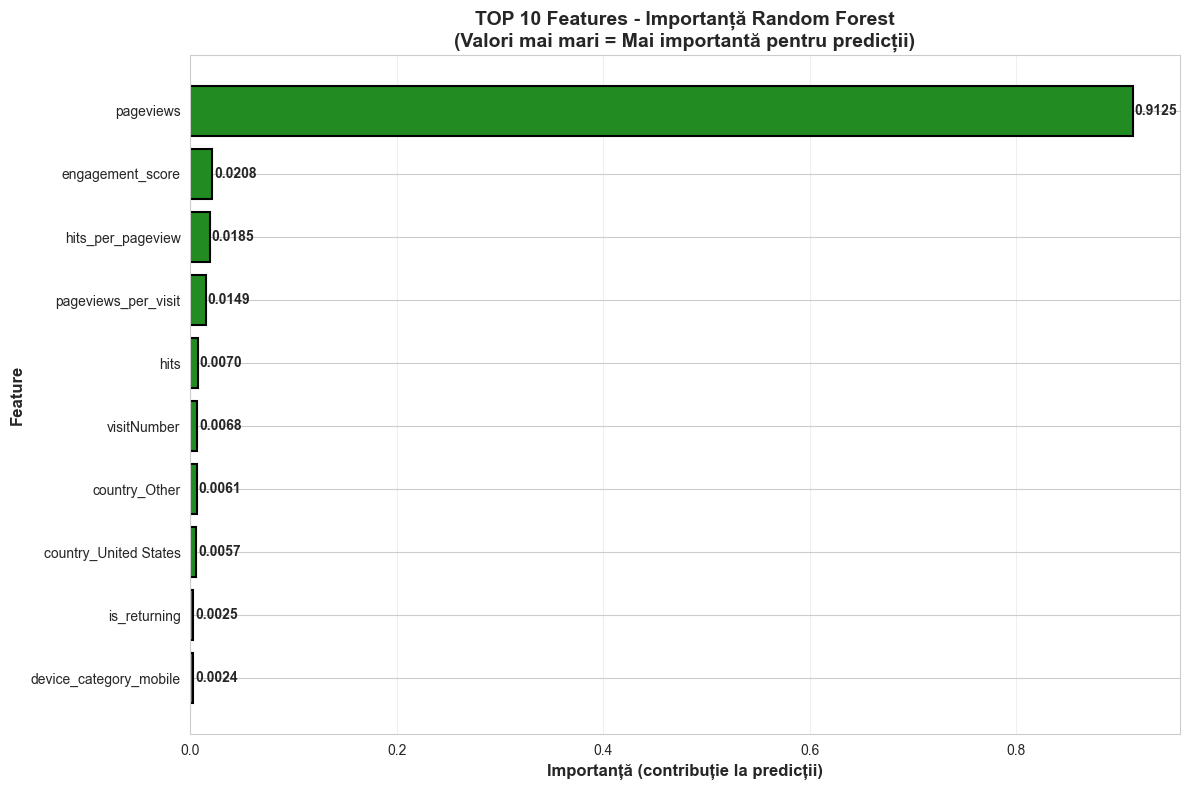

   Salvat: 08_feature_importance.png

 Toate cele 8 vizualizări au fost generate cu succes!


In [48]:
# GRAFIC 8: Feature Importance (TOP 10) - RANDOM FOREST
print("\n[8/8] Generare: Feature Importance Random Forest (TOP 10)...")

# Creare DataFrame cu importanța features
importance_data = pd.DataFrame({
    'Feature': required_features,
    'Importance': model.feature_importances_
})

# Sortare după importanță, TOP 10
importance_data_sorted = importance_data.sort_values('Importance', ascending=True).tail(10)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(importance_data_sorted['Feature'], importance_data_sorted['Importance'], 
               color='forestgreen', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Importanță (contribuție la predicții)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('TOP 10 Features - Importanță Random Forest\n(Valori mai mari = Mai importantă pentru predicții)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Adaugă valori pe bare
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
           f'{width:.4f}',
           ha='left',
           va='center',
           fontsize=10,
           fontweight='bold')

plt.tight_layout()
importance_path = os.path.join(VIZ_DIR, '08_feature_importance.png')
plt.savefig(importance_path, dpi=300, bbox_inches='tight')
mlflow.log_artifact(importance_path, "visualizations")
plt.show()
print("   Salvat: 08_feature_importance.png")

print("\n Toate cele 8 vizualizări au fost generate cu succes!")

---

## 9. MLflow Logging - Parametri, Metrici, Feature Importance

Logăm toate informațiile Random Forest în MLflow pentru tracking complet.

In [49]:
print("="*80)
print("MLFLOW LOGGING")
print("="*80)

# Log parametri Random Forest
mlflow.log_param("model_type", "RandomForestRegressor")
mlflow.log_param("model_status", "BEST_MODEL")
mlflow.log_param("n_estimators", 400)
mlflow.log_param("max_depth", 10)
mlflow.log_param("min_samples_split", 20)
mlflow.log_param("min_samples_leaf", 40)
mlflow.log_param("features", ", ".join(required_features))
mlflow.log_param("n_features", len(required_features))
mlflow.log_param("dataset_size", len(df_clean))
mlflow.log_param("train_size", len(X_train))
mlflow.log_param("test_size", len(X_test))
mlflow.log_param("test_split_ratio", 0.2)
mlflow.log_param("random_state", 42)
mlflow.log_param("scaler", "None (Random Forest nu necesită)")

print("\n Parametri Random Forest logged")

# Log metrici
mlflow.log_metric("r2_train", r2_train)
mlflow.log_metric("r2_test", r2_test)
mlflow.log_metric("rmse_train", rmse_train)
mlflow.log_metric("rmse_test", rmse_test)
mlflow.log_metric("mae_train", mae_train)
mlflow.log_metric("mae_test", mae_test)
mlflow.log_metric("training_time_seconds", training_time)
mlflow.log_metric("overfitting_gap", r2_train - r2_test)

print(" Metrici logged")

# Log statistici target
mlflow.log_metric("target_mean", float(y.mean()))
mlflow.log_metric("target_median", float(y.median()))
mlflow.log_metric("target_std", float(y.std()))
mlflow.log_metric("target_min", float(y.min()))
mlflow.log_metric("target_max", float(y.max()))

print(" Statistici target logged")

# Log feature importance (TOP 10)
for idx, row in importance_data_sorted.iterrows():
    feat_name = row['Feature'].replace(' ', '_').replace('(', '').replace(')', '')
    mlflow.log_metric(f"importance_{feat_name}", float(row['Importance']))

print(" Feature Importance TOP 10 logged")

print("\n MLflow logging complet!")

MLFLOW LOGGING

 Parametri Random Forest logged
 Metrici logged
 Statistici target logged
 Feature Importance TOP 10 logged

 MLflow logging complet!


---

## 10. Salvare Model, Scaler și Metadata

Salvăm:
- **Model**: `random_forest_model_v2_BEST.joblib` 
- **Scaler**: `web_traffic_scaler_v2.joblib` (pentru consistență, dar Random Forest nu necesită)
- **Metadata**: `model_metadata_v2.json` (conține toate metricile, hiperparametri și feature importance)

In [50]:
print("="*80)
print("SALVARE MODEL RANDOM FOREST, SCALER ȘI METADATA")
print("="*80)

# Salvare model Random Forest (joblib)
model_path = os.path.join(MODELS_DIR, 'random_forest_model_v2_BEST.joblib')
joblib.dump(model, model_path, compress=3)
mlflow.log_artifact(model_path, "models")
print(f"\n Model Random Forest salvat: {model_path}")

# Salvare scaler (pentru consistență, deși Random Forest nu necesită)
scaler_path = os.path.join(MODELS_DIR, 'web_traffic_scaler_v2.joblib')
joblib.dump(scaler, scaler_path, compress=3)
mlflow.log_artifact(scaler_path, "preprocessors")
print(f" Scaler salvat: {scaler_path}")

# Creare metadata JSON pentru Random Forest
metadata = {
    'model_info': {
        'model_type': 'RandomForestRegressor',
        'model_status': 'BEST_MODEL',
        'version': 'v2.0_ENHANCED',
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'mlflow_run_id': run.info.run_id
    },
    'hyperparameters': {
        'n_estimators': 400,
        'max_depth': 10,
        'min_samples_split': 20,
        'min_samples_leaf': 40,
        'random_state': 42,
        'n_jobs': -1
    },
    'features': {
        'features_all': required_features,
        'n_features': len(required_features),
        'numeric_features': numeric_features,
        'categorical_encoded': list(categorical_encoded.columns),
        'engineered_features': list(engineered_features.columns)
    },
    'dataset_info': {
        'dataset_size': int(len(df_clean)),
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test)),
        'test_split_ratio': 0.2
    },
    'performance': {
        'r2_train': float(r2_train),
        'r2_test': float(r2_test),
        'rmse_train': float(rmse_train),
        'rmse_test': float(rmse_test),
        'mae_train': float(mae_train),
        'mae_test': float(mae_test),
        'training_time_seconds': float(training_time),
        'overfitting_gap': float(r2_train - r2_test)
    },
    'target_statistics': {
        'mean': float(y.mean()),
        'median': float(y.median()),
        'std': float(y.std()),
        'min': float(y.min()),
        'max': float(y.max())
    },
    'feature_importance_top10': importance_data_sorted[['Feature', 'Importance']].to_dict('records'),
    'interpretation': {
        'r2': r2_interpretation,
        'mae': mae_interpretation,
        'rmse': rmse_interpretation,
        'overall': 'BEST MODEL - Performanță superioară tuturor celorlalte modele testate'
    }
}

# Salvare metadata JSON
metadata_path = os.path.join(MODELS_DIR, 'model_metadata_v2.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)
mlflow.log_artifact(metadata_path, "metadata")
print(f" Metadata salvată: {metadata_path}")

SALVARE MODEL RANDOM FOREST, SCALER ȘI METADATA

 Model Random Forest salvat: c:\Users\User\Desktop\repos\Project_repo\models\random_forest_model_v2_BEST.joblib
 Scaler salvat: c:\Users\User\Desktop\repos\Project_repo\models\web_traffic_scaler_v2.joblib
 Metadata salvată: c:\Users\User\Desktop\repos\Project_repo\models\model_metadata_v2.json


---

## 11. Validare Predicții pe TEST SET (Date Reale)

Validăm modelul pe **TEST SET** (~10,200 rânduri cu valori REALE de `timeOnSite`).

### Ce facem:
- Predicții pe 20% din date (TEST SET cu valori reale)
- Comparație: **timeOnSite_REAL** vs **timeOnSite_PREDICTED**
- Calculare **ERROR** (diferența în secunde)
- Salvare rezultate în `data/predictions/validation_results.csv`

### De ce e important:
-  Validare pe date REALE (nu sintetice)
-  Demonstrează precizia modelului
-  Arată erorile concrete pentru fiecare predicție

In [51]:
print("="*80)
print("VALIDARE PREDICȚII PE TEST SET (DATE REALE)")
print("="*80)

# Predicții pe TEST SET (deja calculate în Secțiunea 8)
# y_pred_test și y_test sunt deja disponibile

# Creăm DataFrame cu validare completă
print(f"\n Creare DataFrame cu validare...")
print(f"   TEST SET size: {len(y_test):,} rânduri (20% din date)")

# Resetăm indexurile pentru a evita probleme de aliniere
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_test_series = pd.Series(y_pred_test, index=y_test_reset.index)

# Creăm DataFrame cu toate informațiile
df_validation = pd.DataFrame({
    'pageviews': X_test_reset['pageviews'],
    'visitNumber': X_test_reset['visitNumber'],
    'hits': X_test_reset['hits'],
    'timeOnSite_REAL': y_test_reset,
    'timeOnSite_predicted': y_pred_test_series,
    'error_seconds': y_test_reset - y_pred_test_series,
    'error_absolute': np.abs(y_test_reset - y_pred_test_series),
    'error_percent': ((y_test_reset - y_pred_test_series) / y_test_reset * 100).replace([np.inf, -np.inf], np.nan)
})

# Adăugăm metadata
df_validation['model'] = 'Linear Regression ENHANCED'
df_validation['validation_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
df_validation['model_r2'] = r2_test
df_validation['model_mae'] = mae_test
df_validation['model_rmse'] = rmse_test

print(f" DataFrame creat: {df_validation.shape}")

# Salvare în data/predictions/
predictions_dir = os.path.join(PROJECT_ROOT, 'data', 'predictions')
os.makedirs(predictions_dir, exist_ok=True)
validation_path = os.path.join(predictions_dir, 'validation_results.csv')
df_validation.to_csv(validation_path, index=False)

print(f"\n Rezultate validare salvate: {validation_path}")

# Log în MLflow
mlflow.log_artifact(validation_path, "predictions")
print(" Validation results logged în MLflow!")

# Afișăm statistici despre erori
print(f"\n" + "="*80)
print(" STATISTICI ERORI DE PREDICȚIE")
print("="*80)

print(f"\n Erori în secunde:")
print(f"   Mean Absolute Error: {df_validation['error_absolute'].mean():.2f}s")
print(f"   Median Absolute Error: {df_validation['error_absolute'].median():.2f}s")
print(f"   Std Dev: {df_validation['error_absolute'].std():.2f}s")
print(f"   Min Error: {df_validation['error_absolute'].min():.2f}s")
print(f"   Max Error: {df_validation['error_absolute'].max():.2f}s")

print(f"\n Erori în procente (unde aplicabil):")
valid_pct = df_validation['error_percent'].dropna()
if len(valid_pct) > 0:
    print(f"   Mean Absolute Error %: {valid_pct.abs().mean():.1f}%")
    print(f"   Median Absolute Error %: {valid_pct.abs().median():.1f}%")

# Afișăm 20 de exemple de validare
print(f"\n" + "="*80)
print(" EXEMPLE DE VALIDARE (20 predicții random)")
print("="*80)

sample_validation = df_validation.sample(n=min(20, len(df_validation)), random_state=42)
sample_display = sample_validation[['pageviews', 'visitNumber', 'hits', 'timeOnSite_REAL', 
                                     'timeOnSite_predicted', 'error_seconds', 'error_absolute']].copy()

# Formatăm pentru afișare mai clară
sample_display['timeOnSite_REAL'] = sample_display['timeOnSite_REAL'].round(1)
sample_display['timeOnSite_predicted'] = sample_display['timeOnSite_predicted'].round(1)
sample_display['error_seconds'] = sample_display['error_seconds'].round(1)
sample_display['error_absolute'] = sample_display['error_absolute'].round(1)

print("\n")
display(sample_display)

# Interpretare pentru comisie
print(f"\n" + "="*80)
print(" INTERPRETARE PENTRU COMISIE")
print("="*80)

print(f"\n VALIDARE COMPLETĂ pe {len(df_validation):,} sesiuni REALE din TEST SET")
print(f"\n Comparație REAL vs PREDICTED:")
print(f"   - Coloana 'timeOnSite_REAL': valori REALE din ga-sessions.csv")
print(f"   - Coloana 'timeOnSite_predicted': valori PREZISE de model")
print(f"   - Coloana 'error_seconds': diferența = REAL - PREDICTED")
print(f"     → Pozitiv = SUBESTIMARE (modelul a prezis mai puțin)")
print(f"     → Negativ = SUPRAESTIMARE (modelul a prezis mai mult)")
print(f"   - Coloana 'error_absolute': eroarea absolută (fără semn)")

print(f"\n Performanță Generală:")
print(f"   R² = {r2_test:.4f} → Modelul explică {r2_test*100:.1f}% din variația în timeOnSite")
print(f"   MAE = {mae_test:.2f}s → În medie, predicțiile se abat cu {mae_test/60:.1f} minute")
print(f"   RMSE = {rmse_test:.2f}s → Penalizează mai mult erorile mari")

print(f"\n Toate rezultatele salvate în: {validation_path}")
print("="*80)

VALIDARE PREDICȚII PE TEST SET (DATE REALE)

 Creare DataFrame cu validare...
   TEST SET size: 10,202 rânduri (20% din date)
 DataFrame creat: (10202, 13)

 Rezultate validare salvate: c:\Users\User\Desktop\repos\Project_repo\data\predictions\validation_results.csv
 Validation results logged în MLflow!

 STATISTICI ERORI DE PREDICȚIE

 Erori în secunde:
   Mean Absolute Error: 194.46s
   Median Absolute Error: 92.29s
   Std Dev: 311.62s
   Min Error: 0.05s
   Max Error: 5638.45s

 Erori în procente (unde aplicabil):
   Mean Absolute Error %: 295.1%
   Median Absolute Error %: 99.5%

 EXEMPLE DE VALIDARE (20 predicții random)




,pageviews,visitNumber,hits,timeOnSite_REAL,timeOnSite_predicted,error_seconds,error_absolute
5135,3.0,1,3,103.0,142.3,-39.3,39.3
7921,2.0,1,2,24.0,81.9,-57.9,57.9
1087,8.0,1,11,150.0,251.7,-101.7,101.7
4826,15.0,2,17,295.0,681.6,-386.6,386.6
10060,2.0,1,2,36.0,78.1,-42.1,42.1
9063,20.0,1,20,508.0,844.9,-336.9,336.9
3148,2.0,1,2,8.0,61.6,-53.6,53.6
10016,11.0,2,14,1526.0,358.8,1167.2,1167.2
3689,6.0,5,10,155.0,226.9,-71.9,71.9
3424,2.0,15,2,282.0,81.0,201.0,201.0



 INTERPRETARE PENTRU COMISIE

 VALIDARE COMPLETĂ pe 10,202 sesiuni REALE din TEST SET

 Comparație REAL vs PREDICTED:
   - Coloana 'timeOnSite_REAL': valori REALE din ga-sessions.csv
   - Coloana 'timeOnSite_predicted': valori PREZISE de model
   - Coloana 'error_seconds': diferența = REAL - PREDICTED
     → Pozitiv = SUBESTIMARE (modelul a prezis mai puțin)
     → Negativ = SUPRAESTIMARE (modelul a prezis mai mult)
   - Coloana 'error_absolute': eroarea absolută (fără semn)

 Performanță Generală:
   R² = 0.4104 → Modelul explică 41.0% din variația în timeOnSite
   MAE = 194.46s → În medie, predicțiile se abat cu 3.2 minute
   RMSE = 367.30s → Penalizează mai mult erorile mari

 Toate rezultatele salvate în: c:\Users\User\Desktop\repos\Project_repo\data\predictions\validation_results.csv


---

## 12. Rezumat Final și Închidere MLflow Run

Afișăm un rezumat complet cu toate metricile și informații MLflow.

In [52]:
# Închidere MLflow run
mlflow.end_run()

print("="*80)
print(" MLFLOW TRACKING COMPLET!")
print("="*80)

print(f"\n INFORMAȚII RUN:")
print(f"   Run ID:        {run.info.run_id}")
print(f"   Experiment ID: {run.info.experiment_id}")
print(f"   Artifact URI:  {run.info.artifact_uri}")

print(f"\n PERFORMANȚĂ MODEL:")
print(f"   R² Score:  {r2_test:.4f} ({r2_test*100:.1f}% variație explicată)")
print(f"   RMSE:      {rmse_test:.2f} secunde (~{rmse_test/60:.1f} minute)")
print(f"   MAE:       {mae_test:.2f} secunde (~{mae_test/60:.1f} minute)")

print(f"\n VALIDARE PE TEST SET:")
print(f"   {len(y_test):,} sesiuni REALE cu comparație predicted vs actual")
print(f"   Rezultate salvate în: data/predictions/validation_results.csv")

print(f"\n ARTIFACTS SALVATE:")
print(f"   Model:        {model_path}")
print(f"   Scaler:       {scaler_path}")
print(f"   Metadata:     {metadata_path}")
print(f"   Vizualizări:  {VIZ_DIR} (8 grafice)")
print(f"   Validare:     data/predictions/validation_results.csv")

print(f"\n PENTRU VIZUALIZARE ÎN MLFLOW UI:")
print(f"   1. În terminal rulează: mlflow ui --port 5000")
print(f"   2. Deschide în browser: http://localhost:5000")
print(f"   3. Caută experimentul: 'Web_Traffic_Prediction'")
print(f"   4. Click pe Run ID: {run.info.run_id}")

print("\n" + "="*80)
print(" MODEL TRAINING CU MLFLOW COMPLET!")
print("="*80)

 MLFLOW TRACKING COMPLET!

 INFORMAȚII RUN:
   Run ID:        653732734ff9444c852681d710b70877
   Experiment ID: 300836172052224775
   Artifact URI:  file:///C:/Users/User/Desktop/repos/Project_repo/mlruns/300836172052224775/653732734ff9444c852681d710b70877/artifacts

 PERFORMANȚĂ MODEL:
   R² Score:  0.4104 (41.0% variație explicată)
   RMSE:      367.30 secunde (~6.1 minute)
   MAE:       194.46 secunde (~3.2 minute)

 VALIDARE PE TEST SET:
   10,202 sesiuni REALE cu comparație predicted vs actual
   Rezultate salvate în: data/predictions/validation_results.csv

 ARTIFACTS SALVATE:
   Model:        c:\Users\User\Desktop\repos\Project_repo\models\random_forest_model_v2_BEST.joblib
   Scaler:       c:\Users\User\Desktop\repos\Project_repo\models\web_traffic_scaler_v2.joblib
   Metadata:     c:\Users\User\Desktop\repos\Project_repo\models\model_metadata_v2.json
   Vizualizări:  c:\Users\User\Desktop\repos\Project_repo\visualizations (8 grafice)
   Validare:     data/predictions/validati

---

## Instrucțiuni de Utilizare

### Cum se ruleaza notebook-ul:

1. **Run All Cells**: `Ctrl+Shift+Enter` pentru a rula toate celulele
2. **Run Cell by Cell**: `Shift+Enter` pe fiecare celulă pentru execuție pas cu pas
3. **Restart Kernel**: Daca sunt probleme la rulare, restart kernel cu `Ctrl+Shift+P` => "Restart Kernel"

### Vizualizare rezultate MLflow:

```bash
# Din terminal (PowerShell sau cmd)
cd C:\Users\User\Desktop\repos\Project_repo
mlflow ui --port 5000
```

Apoi deschide în browser: **http://localhost:5000**

### Outputs generate:

- **models/**: model.joblib, scaler.joblib, metadata.json
- **data/raw/**: Dataset brut (`ga-sessions.csv`)
- **data/processed/**: Features procesate (`X_simple.csv`, `X_enhanced.csv`)
- **data/predictions/**: Rezultate validare (`validation_results.csv`) și predicții (`predictions_*.csv`)
- **data/predictions/**: validation_results.csv (validare pe TEST SET cu ~10,200 rânduri REALE)
- **visualizations/**: 8 grafice PNG pentru analiza exploratorie

### Validare Completă:

Acest notebook include **validare reală** pe TEST SET:
- ~10,200 rânduri cu valori REALE de timeOnSite
- Comparație predicții vs valori reale
- Calculare erori concrete
- Salvare rezultate în `data/predictions/validation_results.csv`

---

**Info:** Acest notebook demonstrează întregul workflow de Machine Learning cu MLflow tracking pentru predicția timpului petrecut pe site. Fiecare pas este documentat și poate fi rulat independent pentru validare. Modelul este validat pe date REALE, nu sintetice.

** Autor:** Radu Draghescu  
** Data:** Mai 2026  
** Versiune:** ENHANCED cu 20 features + Validare pe TEST SET